Libraries imported

Dataset Shape: (6435, 8)

First 5 Rows:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Column Names:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Data Types:
Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64

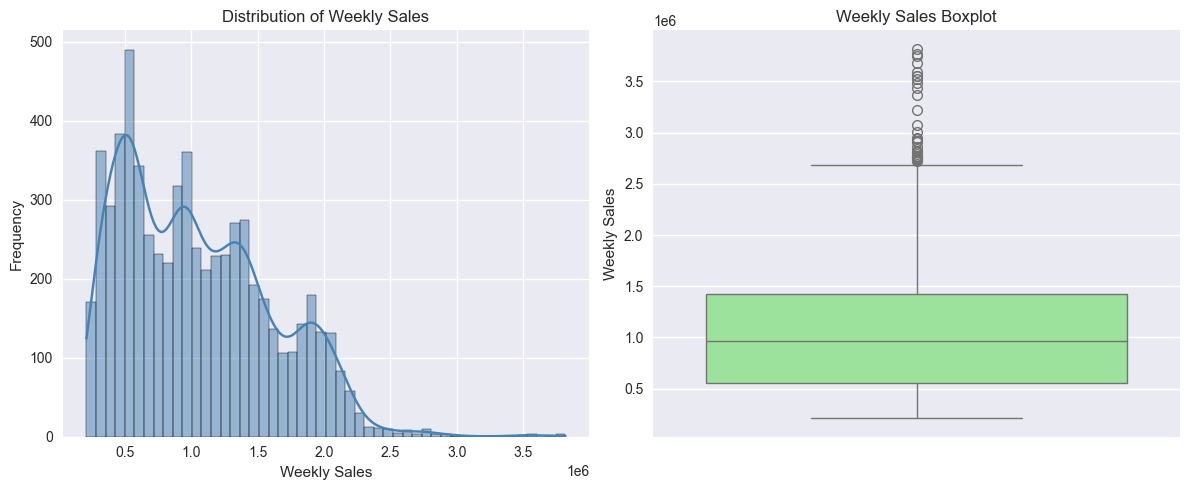

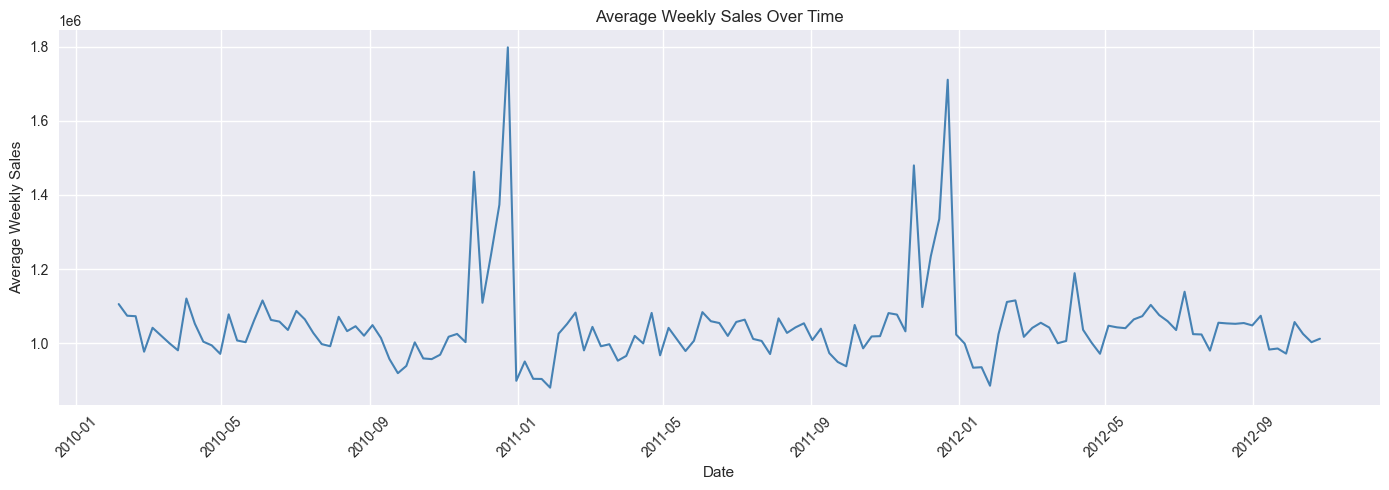

C:\Users\sahoo\AppData\Local\Temp\ipykernel_15636\2563833463.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


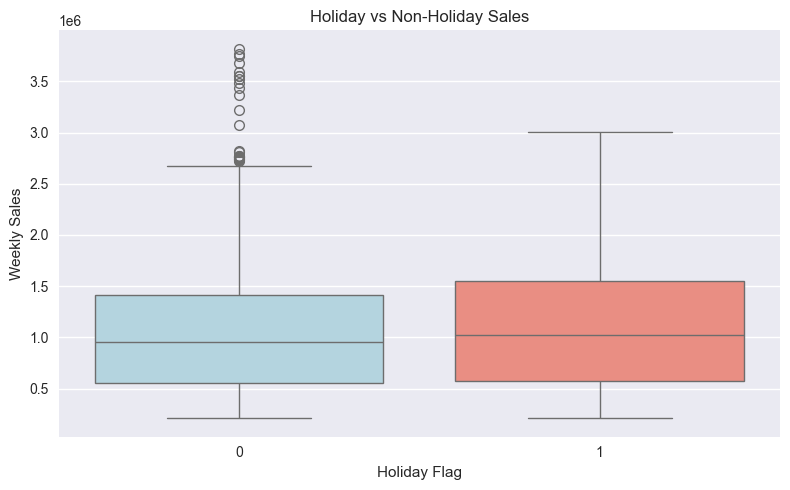

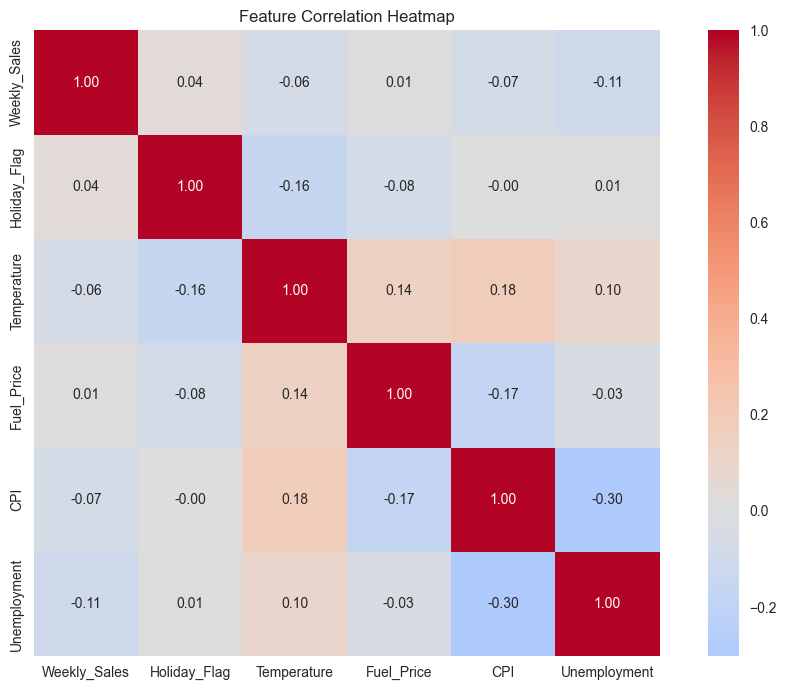

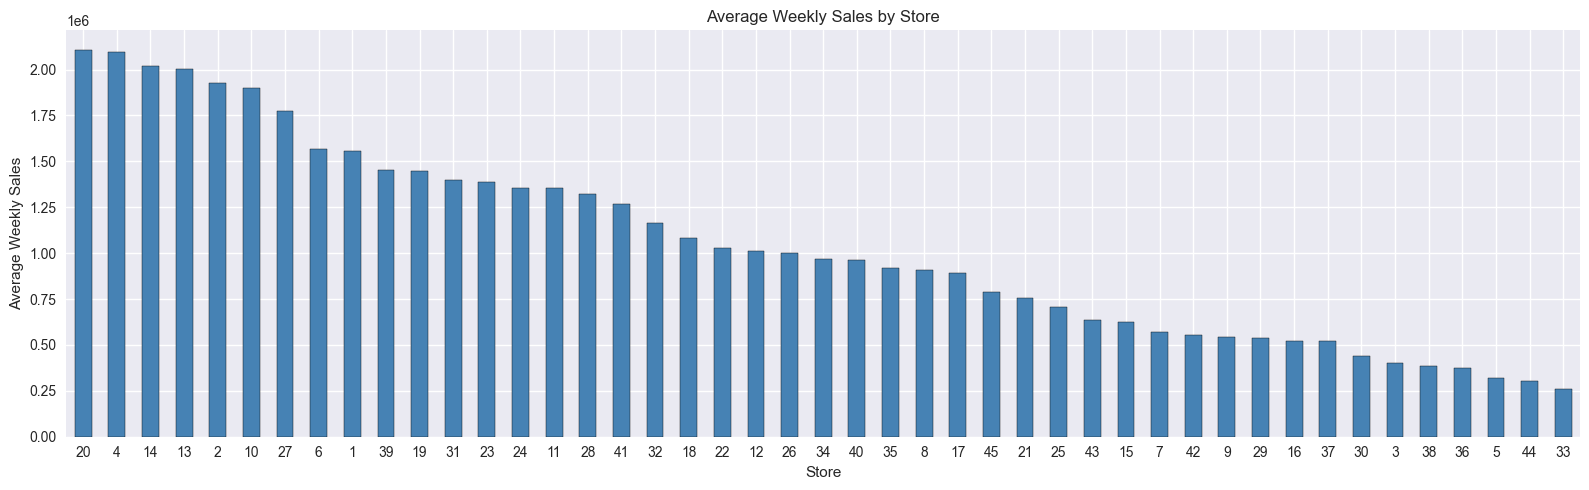

C:\Users\sahoo\AppData\Local\Temp\ipykernel_15636\2563833463.py:242: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


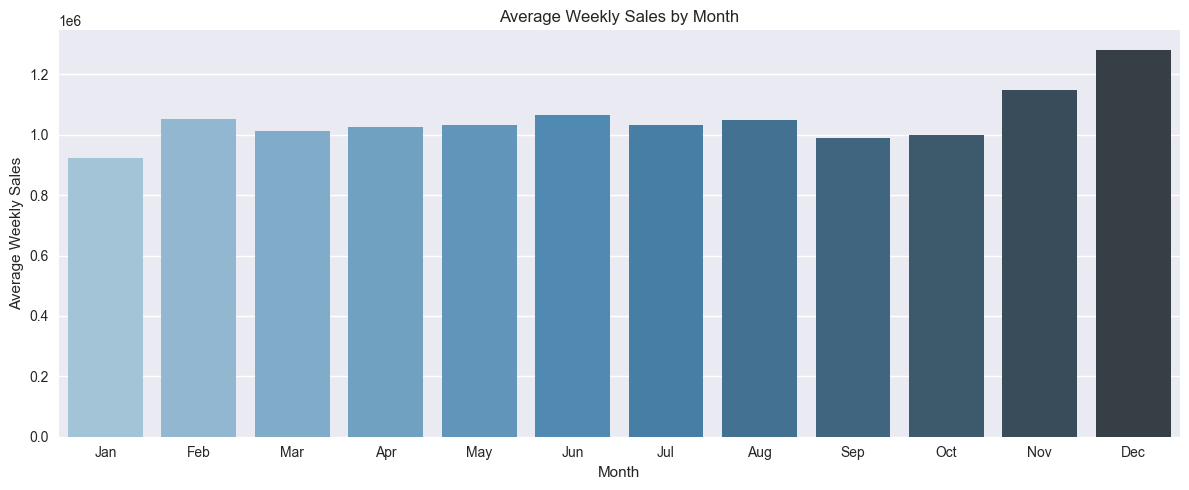


EDA completed successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# basic settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("Libraries imported")

# ---------------- LOAD DATA ---------------- #

# reading walmart dataset
df = pd.read_csv('../data/Walmart.csv')

print("\nDataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ---------------- DATA OVERVIEW ---------------- #

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# ---------------- DATE HANDLING ---------------- #

# converting date column into datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print("\nDate Range:",
      df['Date'].min(),
      "to",
      df['Date'].max())

print("\nTotal Stores:", df['Store'].nunique())

print("\nTotal Weeks:", df['Date'].nunique())

print("\nBasic Statistics:")
print(df.describe())

# ---------------- FEATURE EXTRACTION ---------------- #

# extracting useful values from date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter

print("\nNew Time Features Added:")
print(df[['Date', 'Year', 'Month', 'Week', 'Quarter']].head())

# ---------------- SALES DISTRIBUTION ---------------- #

plt.figure(figsize=(12, 5))

# histogram
plt.subplot(1, 2, 1)

sns.histplot(
    df['Weekly_Sales'],
    bins=50,
    color='steelblue',
    kde=True
)

plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

# boxplot
plt.subplot(1, 2, 2)

sns.boxplot(
    y=df['Weekly_Sales'],
    color='lightgreen'
)

plt.title('Weekly Sales Boxplot')
plt.ylabel('Weekly Sales')

plt.tight_layout()

plt.savefig(
    '../outputs/graphs/01_sales_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ---------------- SALES TREND ---------------- #

sales_over_time = (
    df.groupby('Date')['Weekly_Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    sales_over_time['Date'],
    sales_over_time['Weekly_Sales'],
    color='steelblue',
    linewidth=1.5
)

plt.title('Average Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Average Weekly Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../outputs/graphs/02_sales_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ---------------- HOLIDAY IMPACT ---------------- #

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Holiday_Flag',
    y='Weekly_Sales',
    data=df,
    palette=['lightblue', 'salmon']
)

plt.title('Holiday vs Non-Holiday Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Weekly Sales')

plt.tight_layout()

plt.savefig(
    '../outputs/graphs/03_holiday_impact.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ---------------- CORRELATION HEATMAP ---------------- #

correlation = df[
    [
        'Weekly_Sales',
        'Holiday_Flag',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment'
    ]
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Feature Correlation Heatmap')

plt.tight_layout()

plt.savefig(
    '../outputs/graphs/04_correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ---------------- SALES BY STORE ---------------- #

store_sales = (
    df.groupby('Store')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(16, 5))

store_sales.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Average Weekly Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    '../outputs/graphs/05_sales_by_store.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ---------------- MONTHLY SALES PATTERN ---------------- #

monthly_sales = (
    df.groupby('Month')['Weekly_Sales']
    .mean()
    .reset_index()
)

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(12, 5))

sns.barplot(
    x='Month',
    y='Weekly_Sales',
    data=monthly_sales,
    palette='Blues_d'
)

plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')

plt.xticks(
    ticks=range(12),
    labels=month_names
)

plt.tight_layout()

plt.savefig(
    '../outputs/graphs/06_monthly_pattern.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nEDA completed successfully")